In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Day 1  _ missing part 2 and 3

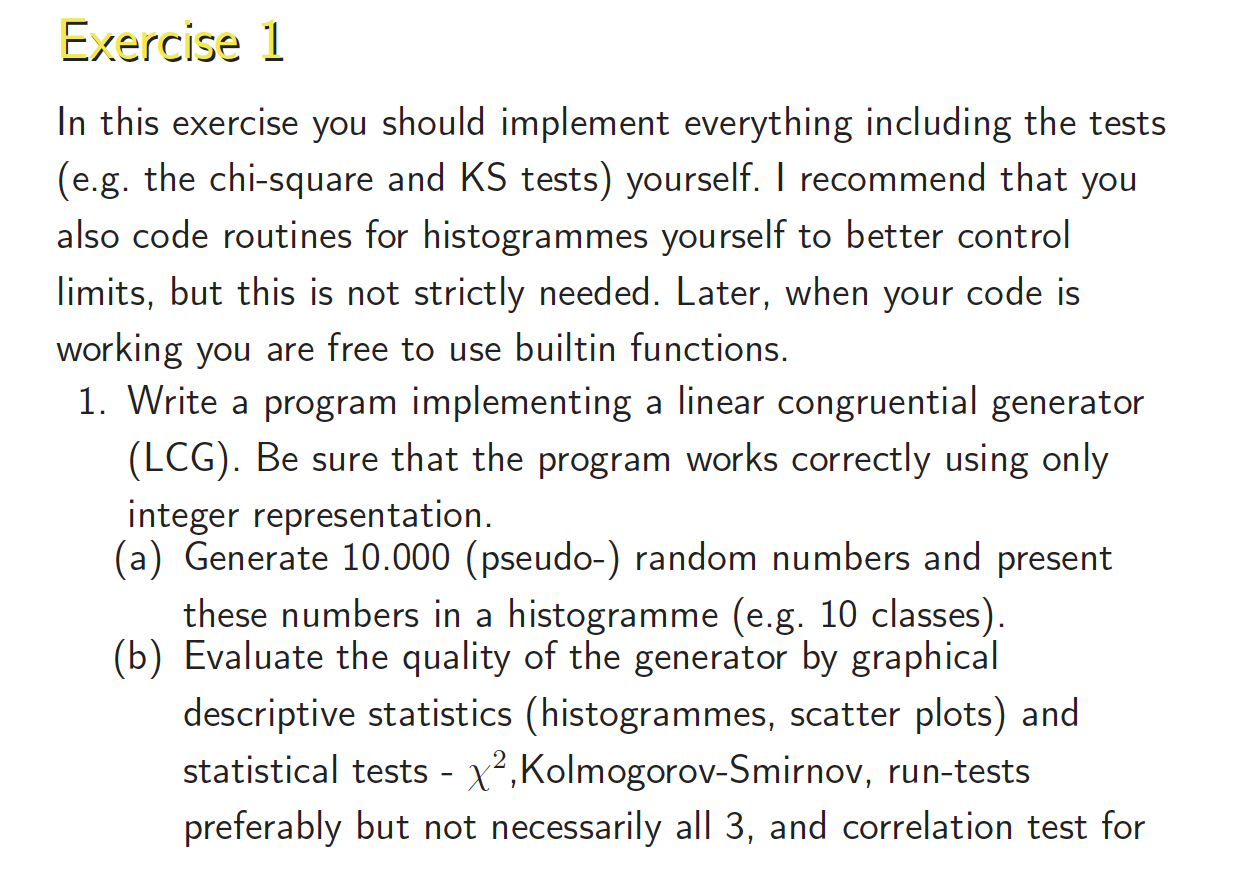

Linear congurential generator (LCG) is defined by $x_i = mod(ax_{i-1}+c, M)$

where, a is the multiplier, c is the increment, M is the modulus.

## (a) Generate 10.000 (pseudo-) random numbers and present these numbers in a histogramme (e.g. 10 classes).

In [3]:
a = 1203515245
c =12345
M = 2**32
# Linear Congurential Generator
def LCG(x0,a,c,M,n):
    x= x0
    numbers = []
    for i in range(n):
        x = (a*x+c)%M
        U=x/M
        numbers.append(U)
    return numbers
LCG(3,a,c,M,10000)

[0.8406485617160797,
 0.7126281692180783,
 0.6703997845761478,
 0.9821126086171716,
 0.7774873180314898,
 0.045064297737553716,
 0.3323677801527083,
 0.36059573176316917,
 0.4589076992124319,
 0.05003916868008673,
 0.35361378407105803,
 0.9716593825723976,
 0.8731706896796823,
 0.5166646346915513,
 0.4036407698877156,
 0.06340551073662937,
 0.7885474972426891,
 0.3381747102830559,
 0.29911891696974635,
 0.6409818117972463,
 0.26570968981832266,
 0.4405754741746932,
 0.7423499659635127,
 0.1623214732389897,
 0.6339865196496248,
 0.5228184091392905,
 0.7657862617634237,
 0.4438438580837101,
 0.6033644350245595,
 0.8428721793461591,
 0.4294794839806855,
 0.3854911259841174,
 0.9341037794947624,
 0.03406784520484507,
 0.06833406491205096,
 0.874475791817531,
 0.8358476785942912,
 0.6860925157088786,
 0.13604029500856996,
 0.9771142217796296,
 0.01809811405837536,
 0.17500643827952445,
 0.44256211584433913,
 0.27812106697820127,
 0.06393418554216623,
 0.9766585261095315,
 0.3320546005852520

3610558080
3060714681
2879345150
4218141535
3339282604
193549685
1427508746
1548746875
1970993560
214916593
1518759638
4173245271
3750239556
2219057709
1733623906
272324595
3386785712
1452449321
1284705966
2752995919
1141214428
1892257253
3188368826
697165419
2722951368
2245487969
3289026950
1906294855
2591430516
3620108445
1844600338
1655671779
4011945184
146320281
293492574
3755844927
3589938444
2946744917
584288618
4196673627
77730808
751646929
1900789814
1194520887
274595236
4194716429
1426163650
4195064787
2357282320
1923609865
421276686
425559087
328866108
3478057669
2933635354
4020356683
660431656
3512188993
1969552102
2432122407
2471677908
1511692669
2722987378
314476483
3191917376
3924261497
2531757246
3505782559
374899052
3267501877
776877258
3713384507
2216812120
719193009
3492888982
1949017879
2418511364
182084589
3563142946
318197683
2808282224
3820895209
2199615854
2361792015
2858964380
3635693477
3189111930
944707115
3008529800
1216807713
508269638
332344327
3194959924
8

(array([ 985.,  902.,  977., 1060., 1017., 1029., 1027.,  949., 1012.,
        1042.]),
 array([7.55286310e-05, 1.00057015e-01, 2.00038501e-01, 3.00019986e-01,
        4.00001472e-01, 4.99982958e-01, 5.99964444e-01, 6.99945930e-01,
        7.99927416e-01, 8.99908902e-01, 9.99890388e-01]),
 <BarContainer object of 10 artists>)

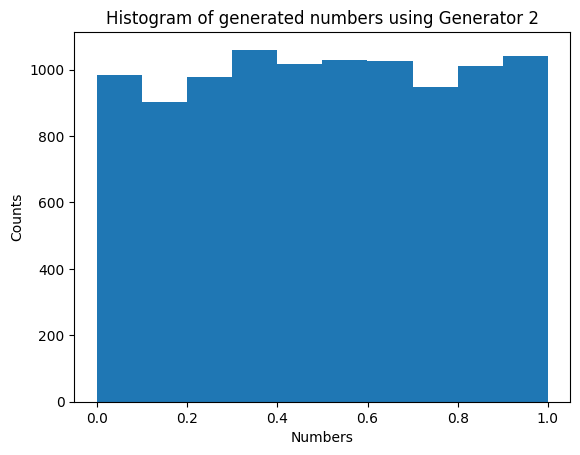

In [4]:

# Linear Congurential Generator

def LCG(x0,a,c,M,n):
    x= x0
    numbers = []
    for i in range(n):
        x = (a*x+c)%M
        print(x)
        U=x/M
        numbers.append(U)
    return numbers

#a=5
#M = 16
x0=3
#c=1
S= 10000

a = 1203515245
c =12345
M = 2**32


numbers= LCG(x0,a,c,M,S)
# I get 3, 0, 1, 6 ... like they did in the slides. 
plt.title("Histogram of generated numbers using Generator 2")
plt.xlabel("Numbers")
plt.ylabel("Counts")
plt.hist(numbers,10)

## (b)
Evaluate the quality of the generator by graphical
descriptive statistics (histogrammes, scatter plots) and
statistical tests -  2,Kolmogorov-Smirnov, run-tests
preferably but not necessarily all 3, and correlation test for some h-values.

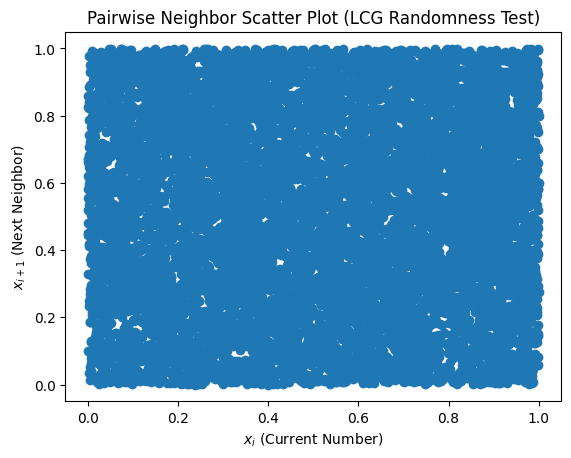

In [5]:

x = np.linspace(0,1,10000)
#now i plot neigboors pairwise
plt.scatter(numbers[:-1],numbers[1:])
# Add titles and labels
plt.title("Pairwise Neighbor Scatter Plot (LCG Randomness Test)")
plt.xlabel("$x_i$ (Current Number)")
plt.ylabel("$x_{i+1}$ (Next Neighbor)")
plt.show()

#### $X^2$ test

the genereal form of the test statistic is 

$ T = \sum_{i=1}^{^n classes} \frac{n_{observed,i} -n_{expected}}{n_{expected,i}}$

In [6]:
#Qhi squared test

m = 0 # number of estimated parameters is zero since have not estimated anything we just choose it ( a, c, M)

# i need to sort the numbers list: 
num_sort = np.sort(numbers)


bins = 10

observed, _ = np.histogram(num_sort, bins=bins)
print(observed)

expected = np.ones(bins) * (S / bins)
print(expected)

def chi_square(n_observed, n_expected, m):

    T = np.sum((n_observed-n_expected)**2/n_expected)
    print(T)
    n_classes = len(n_observed)
    df = n_classes -1 - m

    # Calculate the theoretical Chi-Squared PDF
    pdf = 1-stats.chi2.cdf(T, df)
    pdf2 = stats.chi2.sf(T, df)
    return pdf, pdf2

    
chi_square(observed, expected, m)




[ 985  902  977 1060 1017 1029 1027  949 1012 1042]
[1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.]
20.325999999999997


(np.float64(0.016003738734274298), np.float64(0.016003738734274343))

So T says somthing about how similar our distribution is compared to the Chi2 distribution(?)
So a very low P value means is very unlikly that we observe this if it was truely uniform. 

### now for the Kolmogorovs distribution

$ D_n = \sup_{x}\{| F_n(x)-F(x)|\}$

Supremun ( largest value in set for open sets its the limit value, for closd s
sets its the max.) F is the cdf. 

We have our cdf for the uniform. we need to compare this to where we have our divisions, 

In [7]:

# Empirical cdf is what is based on our numbers, 
# and x is where on the x axis ( between 0 and 
# what he take the cdf from, so if we pick x=1
# then 100 percent of the values will be less 
# than or equal to this. )
def empirical_cdf(x, num_sort):
    numbers = np.array(num_sort)
    F_emp = []
    for val in x:
        count = np.sum(numbers <= val) / len(numbers)
        F_emp.append(count)
    return np.array(F_emp) #np.sum(numbers <= x)/len(numbers)

# Uniform destribtuion
def uniform_cdf(x):
    F = []
    for i in range(len(x)):
        if x[i] < 0: 
            F.append(0)
        if 0 < x[i] < 1:
            F.append((x - 0)/(1-0))
        if x[i] > 1:
            F.append(1)
    return np.array(F)

x = np.linspace(0,1,S)
def Kolmogorovs_dist(x, num_sort):
    D = np.max(np.abs(empirical_cdf(x, num_sort)-uniform_cdf(x)))
    return D

D_n=Kolmogorovs_dist(x, num_sort)

# have to standardize it in order to see where it fits in the table: 
#(sqrt(n) + 0.12 + 0.11/sqrt(n))D_n
standard = (np.sqrt(S) + 0.12+0.11/np.sqrt(S))*D_n
standard

np.float64(1.564614728898891)

This is really bad, but also expected since we repeat the same 16 numbers again and again and again. this is equivalent to have a really low p value. 

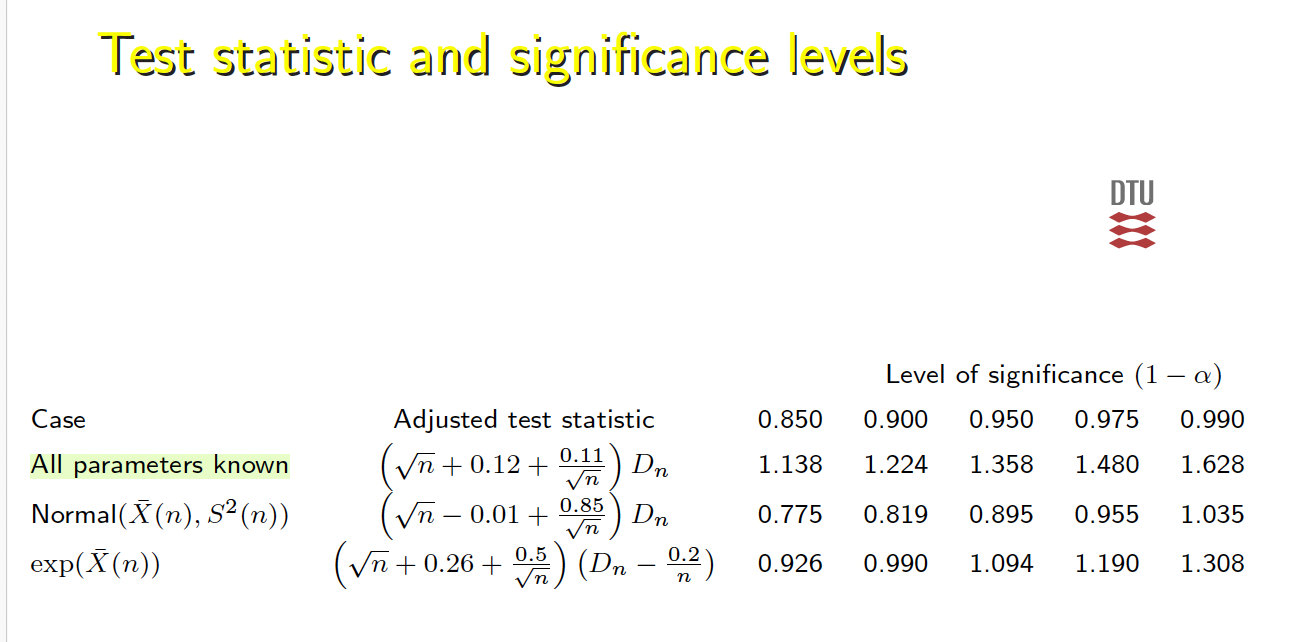

### Run tests

Wald-Wolfowitz

we calculate a 

Run test I

The Wald-Wolfowitz run test, can be used by e.g. comparing with
the median. The number of runs (above/below the median) is (asymptotically)
distributed as

$$ Normal (2 \frac{n_1n_2}{n_1+n_2}+1, 2\frac{n_1n_2(2n_1n_2-n_1-n_2)}{(n_1+n_2)^2(n_1+n_2-1)})$$

where n1 is the number of samples above and n2 is the number
below. 
• The test statistic is the total number of runs T = Ra +Rb with Ra
(runs above) and Rb (runs below)

A run is every time like above and bellow, so if its above, above, above, bellow, bellow, there is 2 runs. 


In [8]:
def Wald_Wolfowiz(numbers):
    median = np.median(numbers)
    n_1= np.sum(numbers >= median)
    n_2= np.sum(numbers < median)
    # this is the normal dfistribution of how many runs there should be.
    mu = 2*(n_1*n_2)/(n_1+n_2)
    var = n_1*n_2*(2*n_1*n_2-n_1-n_2)/((n_1+n_2)**2*(n_1+n_2-1))
    #remeber to use unsorted numbers especially for the runs

    label = ["Above" if i >= median else "Below" for i in numbers]

    T = 1 # T is Runns above plus runns below , this is how many runs there actually is.
    for i in range(1, len(label)):
        if label[i] != label[i -1]:
            T += 1
    return mu, var, T

mu, var, T = Wald_Wolfowiz(numbers)

standard_T = (T-mu)/(np.sqrt(var))
mu, var, T

(np.float64(5000.0), np.float64(1249.87498749875), 4956)

In [9]:
# So this is how you would do it if you *think* about the numbers
# i have not standardised T here, so its all positive, 
# i know that my T is below the median ( 3751 < 5000) so that is why i dont need to substract the 1
cdf = 2*stats.norm.cdf(T, mu, np.sqrt(var))
cdf

np.float64(0.21328979064234344)

In [10]:
# Here this is the genereal "always right way" we standardise T using the Mu and Var calulated, and we use the Abs of the standard T, and we minus 1. 
cdf = 2*(1-stats.norm.cdf(np.abs(standard_T), 0, 1))
cdf

np.float64(0.21328979064234344)

### Up/Down from Knuth

In [11]:
# New new Knuth working
def knuth(obs):
    obs = np.array(obs)
    n = len(obs)

    # --- Step 1: compute increasing runs ---
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    

    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    


#-----Old knuth not working
def run_UpDown_Knuth(numbers):
    median = np.median(numbers)
    label = ["Above" if i >= median else "Below" for i in numbers]

    T = 1 # Total amount of Runs 
    run_lengths = []  #run length
    current_run_lenght = 1

    for i in range(1, len(label)):
        #increasing run by one when the run its "continued"
        if label[i] == label[i-1]:
            current_run_lenght += 1
        else: 
            #new run
            run_lengths.append(current_run_lenght)
            # remeber to reset the run lenght count
            current_run_lenght = 1
            T += 1

    run_lengths.append(current_run_lenght)
    R = [run_lengths.count(1), run_lengths.count(2),run_lengths.count(3), run_lengths.count(4), run_lengths.count(5), run_lengths.count(6) ]

    # Now calculating N
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ]).flatten()

    n = len(numbers)
    R = np.array(R)
    Z = 1/(n-6)*((R-n*B).T)@A@(R-n*B)


    return T, R,Z

T, R, Z= run_UpDown_Knuth(numbers)

R,Z
    

(array([2425, 1261,  656,  299,  165,   73]), np.float64(171900.5792761875))

In [12]:
# we now compare with a qhi square distribution with degrees of freedom 6
stats.chi2.sf(Z, 6)
#p-value of 0 means that our null hypothesis (of this being a uniform distribution) very likely can be discarded. 

np.float64(0.0)

### Correlation coefficients - h-values

In [13]:



def correlation_coef(num,h):
    n= len(num)
    num= np.array(num)
    c = 1/(n-h)*np.sum(num[:-h]*num[h:])
    c_std = np.abs((c-0.25)/np.sqrt((7/(144*n))))
    return 2*(stats.norm.sf(c_std))
#h is the lag, the larger the h the bigger the rejection. 
correlation_coef(numbers,5)

np.float64(0.014333512957849072)

### (c) Repeat (a) and (b) by experimenting with different values of “a”, “b” and “M”. In the end you should have a decent generator. Report at least one bad and your final choice.

I changed all above to from a=5, x0=3, c=1, M=16

to M=10^8+1, a = 23, c = 1

### 2. Apply a system available generator and perform the various statistical tests you did under Part 1 point (b) for this generator too.

In [14]:
# a system avaiable generator is numpys random generator

Samples2= np.random()

TypeError: 'module' object is not callable

### 3. You were asked to simulate one sample and perform tests on this sample. Discuss the sufficiency of this approach and take action, if needed.

# Day 2

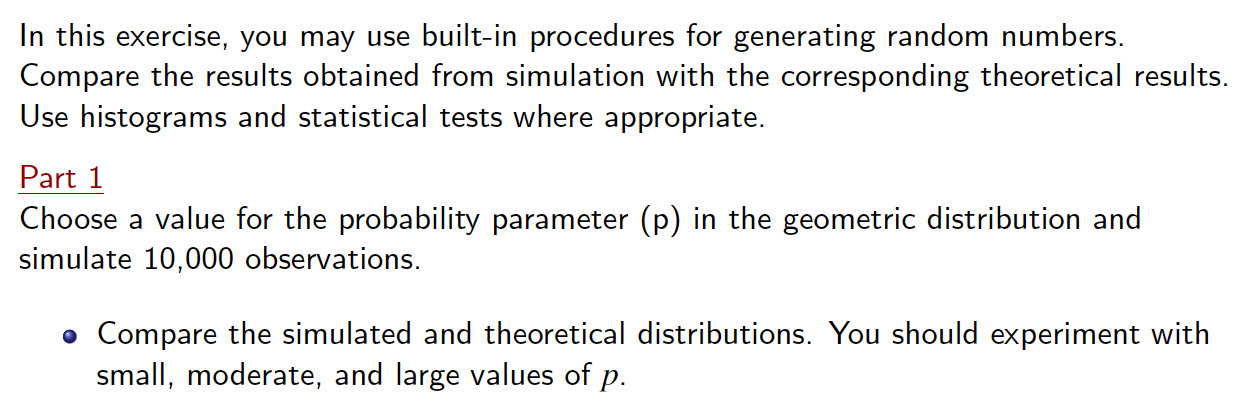

(array([2.599e+03, 0.000e+00, 1.980e+03, 0.000e+00, 0.000e+00, 1.484e+03,
        0.000e+00, 0.000e+00, 1.043e+03, 0.000e+00, 0.000e+00, 7.760e+02,
        0.000e+00, 5.740e+02, 0.000e+00, 0.000e+00, 4.070e+02, 0.000e+00,
        0.000e+00, 2.980e+02, 0.000e+00, 0.000e+00, 2.370e+02, 0.000e+00,
        0.000e+00, 1.730e+02, 0.000e+00, 1.210e+02, 0.000e+00, 0.000e+00,
        8.100e+01, 0.000e+00, 0.000e+00, 6.400e+01, 0.000e+00, 0.000e+00,
        4.000e+01, 0.000e+00, 4.800e+01, 0.000e+00, 0.000e+00, 2.000e+01,
        0.000e+00, 0.000e+00, 1.800e+01, 0.000e+00, 0.000e+00, 9.000e+00,
        0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 4.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 3.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

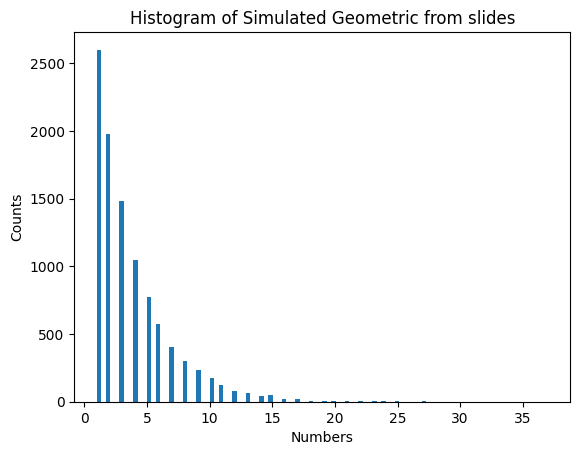

In [ ]:
import numpy as np

np.random.seed(42)
U = np.random.rand(10000) # uniform random numbers

p = [0.002, 0.13, 0.27, 0.68, 98 ]

for i in p:
cdf_5 = stats.geom.cdf(5, p)

def geometric(U):
    logU=np.log(U)
    log1p=np.log(1-p)
    X = np.floor(logU/log1p) + 1
    return X

geometric(U)

 
plt.title("Histogram of Simulated Geometric from slides")
plt.xlabel("Numbers")
plt.ylabel("Counts")
plt.hist(geometric(U),100)

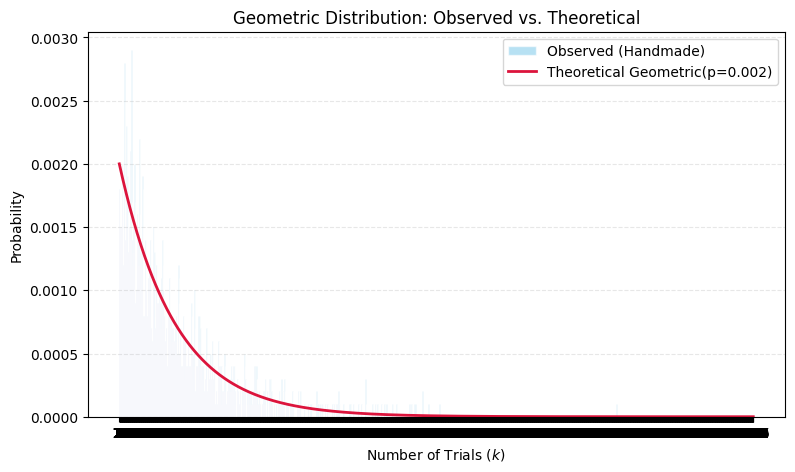

Chi-Squared p=0.002 the p-value is: 0.5574
T:1.000538876048313, Wald_wolfwiz p-value:0.3170497936724864


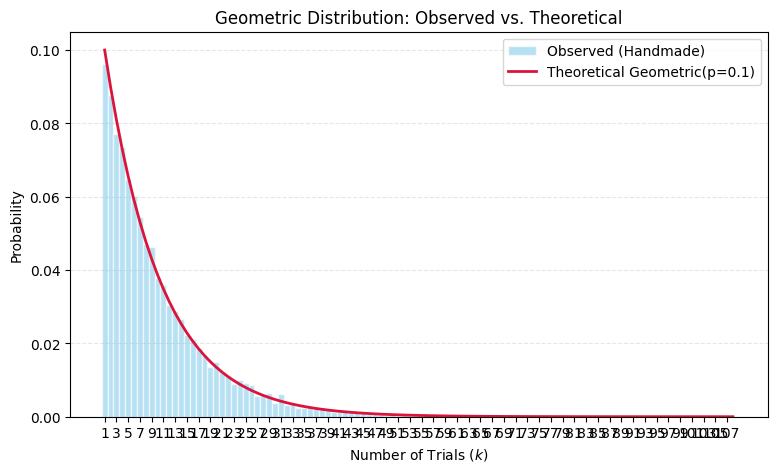

Chi-Squared p=0.1 the p-value is: 0.5412
T:0.4525990260272652, Wald_wolfwiz p-value:0.6508375002402667


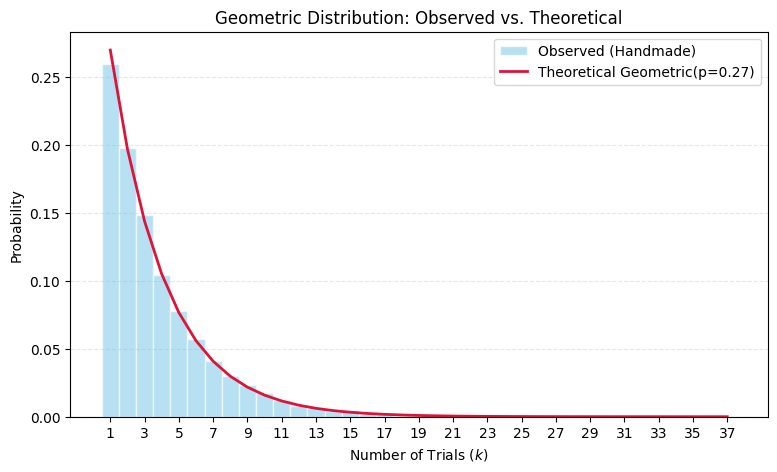

Chi-Squared p=0.27 the p-value is: 0.5572
T:0.31118586734023296, Wald_wolfwiz p-value:0.7556593262735869


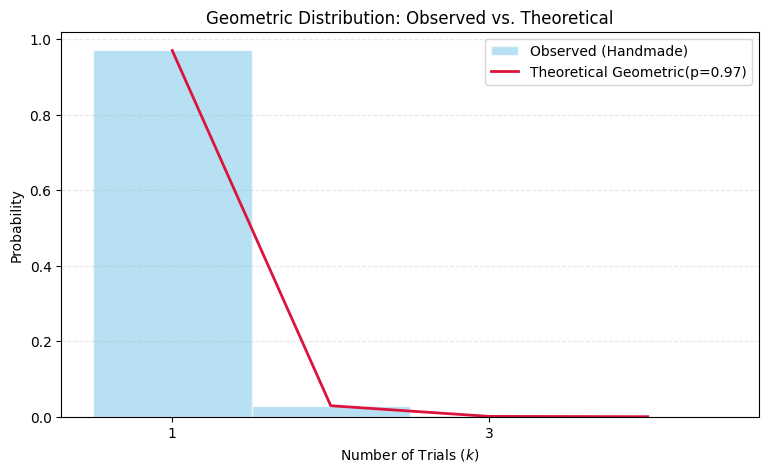

Chi-Squared p=0.97 the p-value is: 0.8179
T:nan, Wald_wolfwiz p-value:nan


In [ ]:
import matplotlib.pyplot as plt  
import numpy as np
import scipy.stats as stats  
from statsmodels.sandbox.stats.runs import runstest_1samp


np.random.seed(42)
U = np.random.rand(10000)  # uniform random numbers
p = [0.002,0.1, 0.27, 0.97]

def geometric(U, p):
    logU = np.log(U)
    log1p = np.log(1 - p)
    X = np.floor(logU / log1p) + 1
    return X


for i in p:
    #constructed geometric
    X = geometric(U, i)
    plt.figure(figsize=(9, 5))
    plt.hist(
        X,
        bins=np.arange(1, int(X.max()) + 2) - 0.5,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="white",
        label="Observed (Handmade)",
    )
    # Theoretical geometric PMF line
    x = np.arange(1, int(X.max()) + 1)
    plt.plot(
        x,
        stats.geom.pmf(x, i),
        "-",
        color="crimson",
        lw=2,
        label=f"Theoretical Geometric(p={i})",
    )

    plt.title("Geometric Distribution: Observed vs. Theoretical")
    plt.xlabel("Number of Trials ($k$)")
    plt.ylabel("Probability")
    plt.xticks(np.arange(1, int(X.max()) + 1, step=2))  
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend()
    plt.show()

# Statistical tests
# Qhi squared test
    
    # Define bins and sample size
    X = geometric(U, i)
    bins = 10  
    N = len(X)
    # I set the range from 0.5 to 10.5 so each integer gets its own bin
    n_observed, _ = np.histogram(X, bins=bins, range=(0.5, bins + 0.5))
    n_observed[-1] = np.sum(X >= bins)


    # expected Counts using the true Geometric PMF instead of a flat line
    k_values = np.arange(1, bins + 1)
    n_expected = stats.geom.pmf(k_values, i) * N

    # Not sure if needed: but this bit is Ensuring total sum of expected matches N perfectly
    # We add any remaining tail probability (k > 10) into the last bin
    leftover_tail_prob = 1.0 - stats.geom.cdf(bins, i)
    n_expected[-1] += leftover_tail_prob * N

    chi2_stat, p_val_chi2 = stats.chisquare(f_obs=n_observed, f_exp=n_expected)
    
    #print(f"Observed counts: {n_observed}")
    #print(f"Expected counts: {n_expected}")
    print(f"Chi-Squared p={i} the p-value is: {p_val_chi2:.4f}")

# Run tests
    T, p = runstest_1samp(X, cutoff="median")
    print(f"T:{T}, Wald_wolfwiz p-value:{p}")

 

    

## Part 2

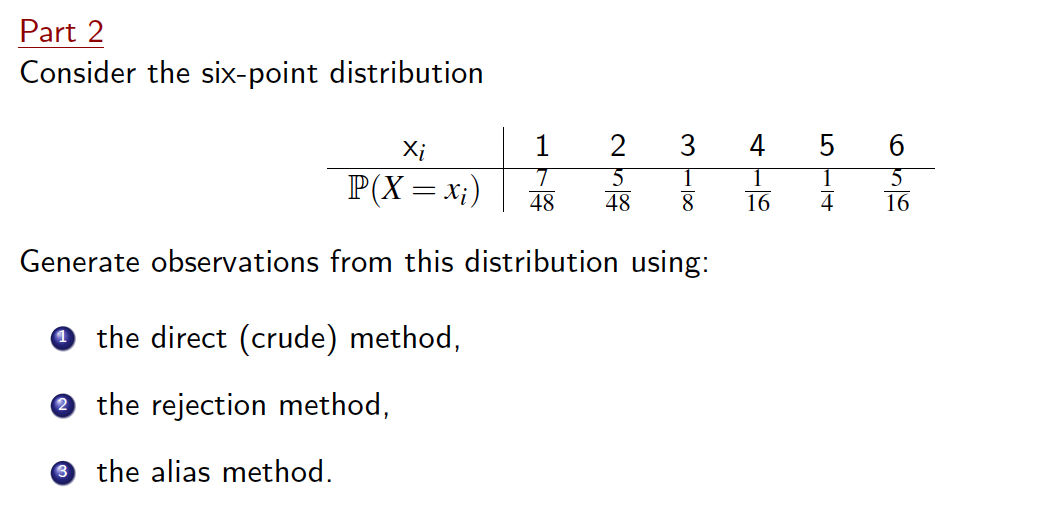

In [ ]:

np.random.seed(42)
U = np.random.rand(10000)  # uniform random numbers
x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
n = 10000
#As it says in the slides, the value x_i is selected whenever U falls into an interval of length p_i. 
def direct_method(U,x,p):
    intervals = np.cumsum(p) # so first interval is 0 to 7/48 nexct is 7/48 to 5/48 and so on
    # search sorted creates these indexes  a[i-1] < v <= a[i] and has numpy.searchsorted(a, v, side='left', sorter=None)
    index= np.searchsorted(intervals, U, side='left', sorter=None)
    X= x[index]
    return X

print(f"The distribution using Direct: {direct_method(U, x,p)}")

def rejection_method(x,p, n):
    samples = []
    k = len(x) # k is the amount of bins to land in
    c = np.max(p)+0.001  # upper value. 

    # we continue undtil we have 10.000 accepted values
    while len(samples) < n: 
        # First we generate a number from U
        U1 = np.random.rand() #U is between 0 and 1
        I = int(np.floor(k*U1)+1) # then the proposal is U scaled so its an integer bertween 1 and 6
        #now the bin is picked

        # now selecting a point between 0 and c U<= pI/c <=> U*c = PI
        U2 = np.random.rand() #
        p_i = p[I - 1] #this is the probability is should be below
        if U2 <= p_i/c:
            samples.append(x[I-1]) # Accept

    return np.array(samples)
    
print(f"The distribution using rejection method {rejection_method(x,p,n)}")

np.random.seed(42)
def alias_tables(p, x, eps):
    k = len(x)
    L = np.arange(1, k +1) #np.arange(1, k+1, 1) # in our case its actually just x, but this is mere genereal
    F = k*p

    G = [idx for idx in range(k) if F[idx] >= 1]
    S = [idx for idx in range(k) if F[idx] < 1]

    #as long as S is not empty we do...
    while len(S) > 0:
        #a)
        j = S[0] #S(1) we remove it afterwards
        i = G[0] 
        #b) 
        L[j]= i
        F[i]= F[i] - (1-F[j])
        if F[i] < 1 - eps :
            G.pop(0)
            S.append(i)
        S.pop(0)
    return F, L
np.random.seed(42)

def alias_method(p, x, eps):
    F, L = alias_tables(p, x, eps)
    samples = []
    k = len(x) # k is the amount of bins to land in

    while len(samples) < n: 
        # First we generate a number from U
        U1 = np.random.rand() #U is between 0 and 1
        I = int(np.floor(k*U1)+1) # then the proposal is U scaled so its an integer bertween 1 and 6
        #now the bin is picked

        U2 = np.random.rand() #
        if U2 <= F[I-1]:
            samples.append(x[I-1]) # Accept
        else:
            samples.append(L[I-1])
    return np.array(samples)
    

np.random.seed(42)
alias_method(p, x, 0.01)









The distribution using Direct: [3 6 6 ... 6 4 2]
The distribution using rejection method [3 5 6 ... 5 3 3]


array([4, 5, 1, ..., 6, 1, 3], shape=(10000,))

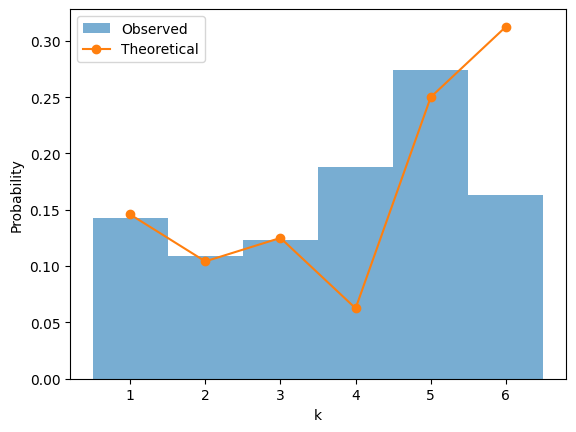

In [ ]:
# Histogram of observed data
np.random.seed(42)
X =alias_method(p, x, 0.01)
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

plt.plot(x, p, 'o-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()



### Part 3 Exercises 3

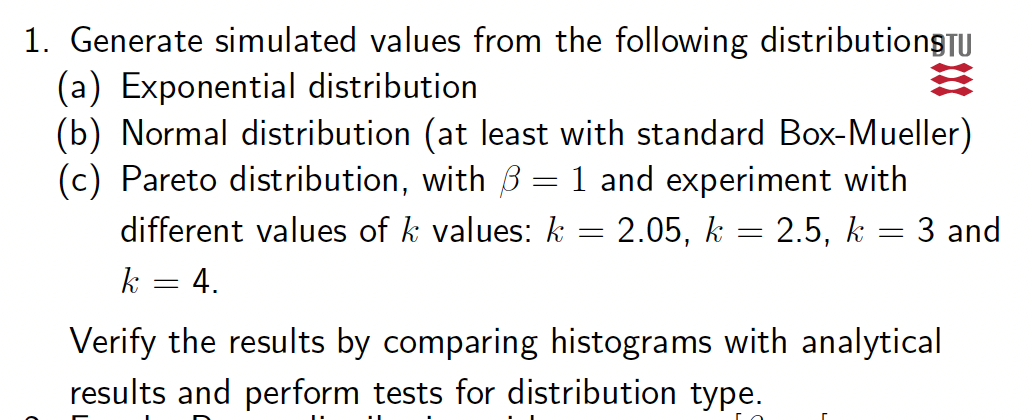

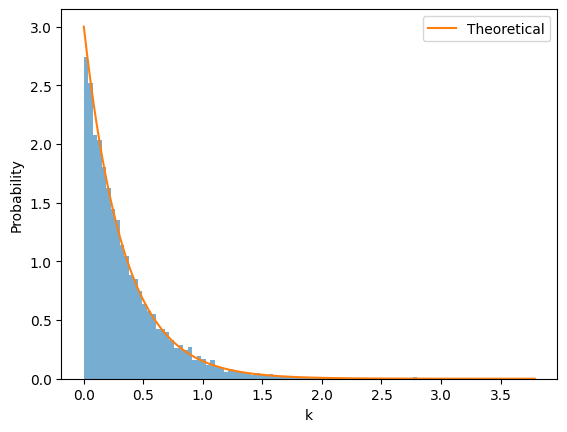

In [ ]:
S= 10000
lamba = 3
#a) Exponential
def exp_samples(lamba, S):
    U = np.random.rand(S) 
    Y = - np.log(U)/lamba
    return Y

np.random.seed(42)
exp_samples = exp_samples(lamba, S)

plt.hist(exp_samples,100,density=True, alpha=0.6) 
# Theoretical
x = np.linspace(np.min(exp_samples),np.max(exp_samples),10000)
theoretical_pdf_exp = lamba*np.exp(-lamba*x)
plt.plot(x, theoretical_pdf_exp, '-', label='Theoretical')
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


In [ ]:
# Bin edges (last bin extends to infinity)

from scipy.stats import chisquare, expon
bin_edges = np.array([
    0.0, 0.1, 0.2, 0.3, 0.5,
    0.8, 1.2, np.inf
])

# Observed frequencies
observed, _ = np.histogram(exp_samples, bins=bin_edges)

# Expected frequencies
cdf_vals = expon(scale=1/lamba).cdf(bin_edges)
expected = S * np.diff(cdf_vals)

# Chi-square goodness-of-fit test
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 7.844806066942353
p-value: 0.2496951749558816


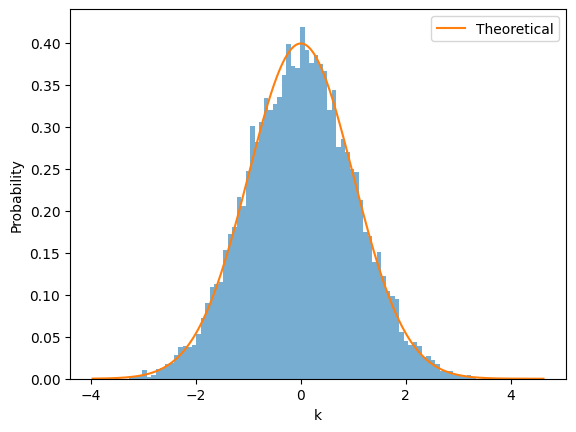

In [ ]:
#b) Normal distribution using Boks Muller Method.

def norm_samples(S, mu, std):
    U1 = np.random.rand(S) 
    U2 = np.random.rand(S) 

    Z1 = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
    return mu + std * Z1
mu= 0
std= 1

np.random.seed(42)
norm_samples = norm_samples(S, mu, std)

plt.hist(norm_samples,100,density=True, alpha=0.6) 
# Theoretical
x = np.linspace(np.min(norm_samples),np.max(norm_samples),10000)
theoretical_pdf_exp = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - mu) / std) ** 2
)
plt.plot(x, theoretical_pdf_exp, '-', label='Theoretical')
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()

In [ ]:
# Qhi test for the normal distribution: 

# Bin edges (last bin extends to infinity)
bin_edges = np.array([
    -np.inf, -4, -2, -1, 0, 1, 2, 4, np.inf
])

# Observed frequencies
observed, _ = np.histogram(norm_samples, bins=bin_edges)

# Expected frequencies
theoretical_cdf = stats.norm(loc=mu, scale= std).cdf(bin_edges)
expected = S * np.diff(theoretical_cdf)

# Chi-square goodness-of-fit test
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)




Chi-square statistic: 7.953712657346525
p-value: 0.33669318618867733


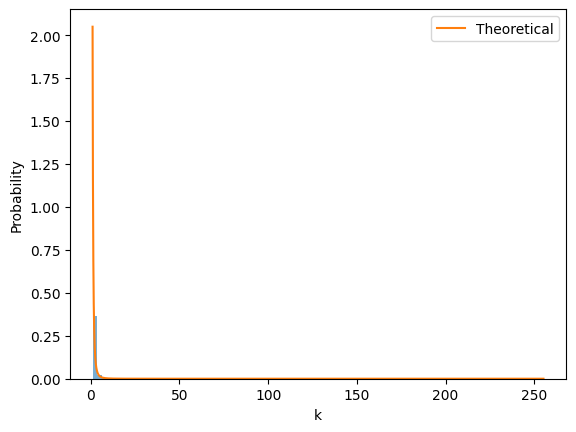

Chi-square statistic: 7.702638950406866
p-value: 0.260708140664208
Calculated expectation: 1.9998743451428789
Theoretical expectation: 1.9523809523809526
difference in expectation: 0.04749339276192632
Calculated variance: 15.481377951704149
Theoretical variance: 37.18820861678019
difference in variance: 21.70683066507604


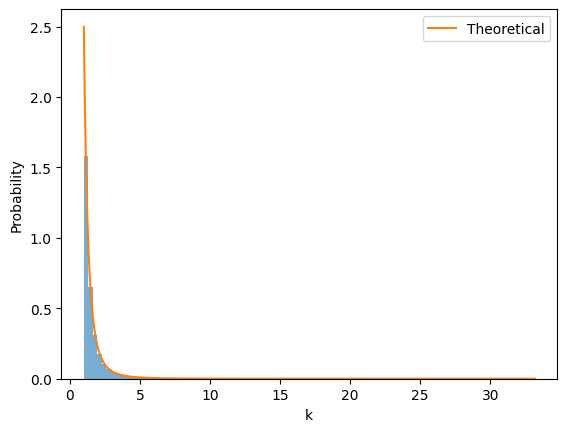

Chi-square statistic: 2.6814308576957013
p-value: 0.8476356894892558
Calculated expectation: 1.6516339420614503
Theoretical expectation: 1.6666666666666667
difference in expectation: 0.01503272460521643
Calculated variance: 1.4191991917244373
Theoretical variance: 2.2222222222222223
difference in variance: 0.803023030497785


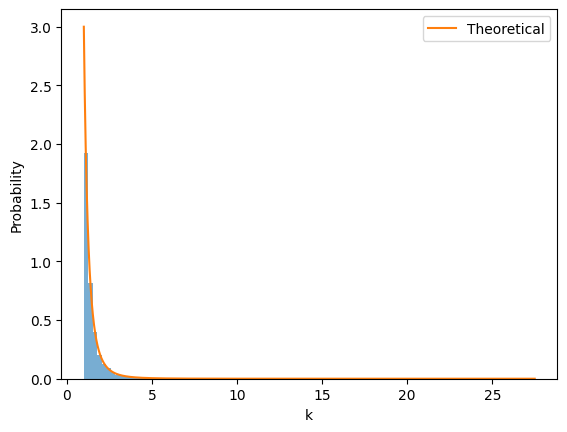

Chi-square statistic: 4.025154813570687
p-value: 0.6732721271005598
Calculated expectation: 1.4945292665012504
Theoretical expectation: 1.5
difference in expectation: 0.005470733498749603
Calculated variance: 0.7155519506587361
Theoretical variance: 0.75
difference in variance: 0.03444804934126389


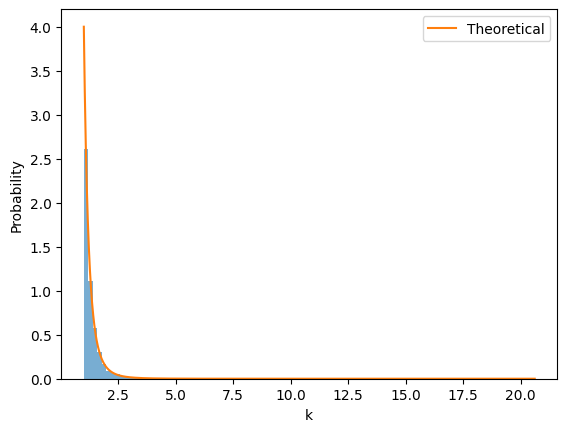

Chi-square statistic: 2.990453641795329
p-value: 0.810044044062114
Calculated expectation: 1.3373669839659401
Theoretical expectation: 1.3333333333333333
difference in expectation: 0.0040336506326068555
Calculated variance: 0.2567325729354677
Theoretical variance: 0.2222222222222222
difference in variance: 0.034510350713245486


In [ ]:
# Pareto distribution 

#exercise 1 c) and 2. 
beta = 1
k = np.array([2.05, 2.5, 3, 4])

np.random.seed(42)
def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)
    #theoretical
    expectation = k /(k-1)*beta  # for k > 1 - theoretical valuer
    variance =  k/((k-1)**2*(k-2))*beta**2 # for k > 2 - theoretical values

    #sample
    sample_expectation = np.mean(F)
    sample_variance = np.var(F)

    return F, expectation, variance, sample_expectation, sample_variance

for i in range(len(k)): 
    F, expectation, variance, sample_expectation, sample_variance = pareto(beta, k[i], S)
    plt.hist(F,100,density=True, alpha=0.6) 
    # Theoretical
    x = np.linspace(np.min(F),np.max(F),10000)
    theoretical_pdf_pareto = k[i]*beta**k[i]/(x**(k[i]+1))

    plt.plot(x, theoretical_pdf_pareto, '-', label='Theoretical')
    plt.xlabel('k')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

    # Qhi test for the pareto distribution: 
    # Bin edges smallest possible value is beta and then tails to infinity. 
    bin_edges =  np.array([beta, 1.2, 1.5, 1.8, 2.2, 3.0, 5.0, np.inf])
    # Observed frequencies
    observed, _ = np.histogram(F, bins=bin_edges)

    # Expected frequencies
    theoretical_cdf = 1.0 - (beta / bin_edges) ** k[i]
    expected = S * np.diff(theoretical_cdf)

    # Chi-square goodness-of-fit test
    chi2_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
    )
    print("Chi-square statistic:", chi2_stat)
    print("p-value:", p_value)
    print(f"Calculated expectation: { sample_expectation}")
    print(f"Theoretical expectation: { expectation}")
    print(f"difference in expectation: {np.abs( expectation-sample_expectation)}")

    print(f"Calculated variance: { sample_variance}")
    print(f"Theoretical variance: { variance}")
    print(f"difference in variance: { np.abs(variance-sample_variance)}")



Discussion of problems 

for the lower k values ( close to 2 we underestimate the variance, get a lower one calculated compared to theoretical, but it becomes less significant when k increases. ) we suspect that this oddity comes from the fraction approcing division with zero. maybe? 

all the means are pretty okay but also become better when wer aproach 2. 

### 3) For the normal distribution generate 100 95% confidence intervals for the mean and variance, each based on 10 observations. Discuss the results.

In [ ]:
import numpy as np
from scipy.stats import t, chi2
S=10000
mu=0
std=1
amount = 100
observations = 10

def norm_samples(S, mu, std):
    U1 = np.random.rand(S) 
    U2 = np.random.rand(S) 

    Z1 = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
    return mu + std * Z1

mu= 0
std= 1
n = 10
def norm_intervals(amount, n, mu, std): 
    mean_lower = []
    mean_upper = []
    stand_lower = []
    stand_upper = []
    # 95% confidense interval 
    for i in range(amount): 
        U= norm_samples(n, mu, std)
        mean = np.mean(U)
        stand = np.std(U, ddof=1)

        #calculate confidense interval for the mean
        CI_mean_upper = mean+t.ppf(0.975, df=n-1)*stand/np.sqrt(n)
        CI_mean_lower = mean-t.ppf(0.975, df=n-1)*stand/np.sqrt(n)
        
        mean_lower.append(CI_mean_lower)
        mean_upper.append(CI_mean_upper)

        CI_std_upper = np.sqrt((n-1)*stand**2/(chi2.ppf(0.025, n-1)))
        CI_std_lower = np.sqrt((n-1)*stand**2/(chi2.ppf(0.975, n-1)))
        
        stand_lower.append(CI_std_lower)
        stand_upper.append(CI_std_upper)
    summary_mean_lower=np.mean(mean_lower)
    summary_mean_upper=np.mean(mean_upper)
    summary_std_lower=np.mean(stand_lower)
    summary_std_upper=np.mean(stand_upper)
    print(f"Mean Lower, upper: {summary_mean_lower,summary_mean_upper},\n std lower, upper: {summary_std_lower,summary_std_upper}")

        

norm_intervals(amount, observations, mu, std)

    


Mean Lower, upper: (np.float64(-0.6922383022290477), np.float64(0.6919712544828553)),
 std lower, upper: (np.float64(0.6654776508608399), np.float64(1.7662701236142002))


So i can see that when i draw the 10 samples i get means that are like centrered around 0 but variang quite a lot, and also a stanard deviation that varies, and i dont get how the mean of the lower variance is larger than the mean of the upper. 

### 4) 

KeyboardInterrupt: 

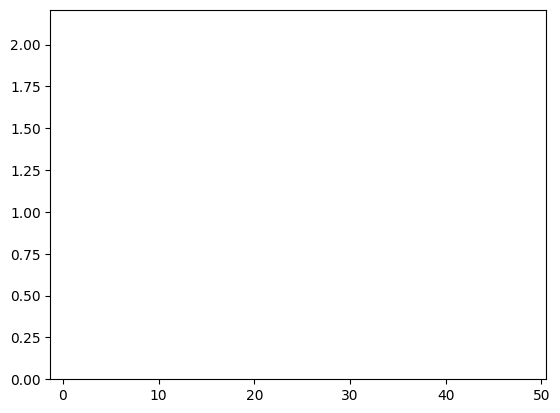

In [5]:
import numpy as np
import matplotlib.pyplot as plt
S = 10000
k = np.array([2.05, 2.5, 3, 4])

def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)

    return F

def composite_distribution(k, S, beta=1):
    samples = []
    for i in range(S):
        #first we uniformely pick a k ( a model) from the k_list
        # Pick exactly one element uniformly at random
        ki = np.random.choice(k)
        #then we pick a number from the pareto distribution using that k
        F= pareto(beta, ki, 1)
        samples.append(F)

    return samples

samples = composite_distribution(k, S, beta=1)
plt.hist(samples,100,density=True, alpha=0.6) 
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()

    


S